## Урок 4. Домашнее задание

### 4.1 Домашнее задание начального уровня

Потренируйтесь в программировании на python. Надо будет найти расстояние от каждой точки из массива $X$ до центра кластера, а потом просуммировать эти расстояния. Это будет реализацией библиотечной функции `sklearn.metrics.pairwise.euclidean_distances` из первого урока.  В итоге у Вас должно получиться число чуть более $16$ - это и будет расстояние.
$$
\sum_{i=1}^{k} \mid x_i - c \mid
$$

где для одного обучающего примера x, состоящего из двух координат:
$$
\mid x - c \mid = (x_1-c_1)^2 + (x_2-c_2)^2
$$

**Примечание** Как вы уже знаете из урока про линейную регрессию, в этой формуле должен быть квадратный корень, но для скорости работы мы опускаем его.

**Подсказка** Средствами библиотеки numpy реализуйте формулу нахождения суммы внутрикластерных расстояний

In [13]:
import numpy as np

clust = np.array([
 [-0.5972191612445694, -0.5919098916910581],
 [-1.5838020751869848, 0.4743393635868491],
 [-1.892642118066139, -1.2770390481464395],
 [-1.021761443519372, -0.38446059106320013],
 [-0.628271339507516, -2.308149346281125],
 [-0.7180915776856387, 1.1805550909358404],
 [-1.543143767548152, -1.4163791359687334],
 [0.022103701018375554, -1.1279478858865397],
 [-0.7776518874305778, -0.4157532453316538],
 [-1.2073577296008344, -1.1308523658604184]
])

centroid = np.array([-0.9774245525274352, -0.032635425821084516])

#сумма эвклидовых расстояний до центроида
def e_sum(points, centroid):
    distances_sq = np.sum((points - centroid)**2, axis=1)
    return np.sum(distances_sq)

e_sum_value = e_sum(clust, centroid)
print(f"сумма эвклидовых расстояний до центроида: {e_sum_value}")



сумма эвклидовых расстояний до центроида: 16.31211696438564


In [14]:
#сумма квадратов расстояний до центроида
def sqrt_sum(points, centroid):
    distances_sq = np.sqrt(np.sum((points - centroid)**2, axis=1))
    return np.sum(distances_sq)

sqrt_sum_value = sqrt_sum(clust, centroid)
print(f"сумма квадратов расстояний до центроида: {sqrt_sum_value}")


сумма квадратов расстояний до центроида: 11.440582444503534


In [8]:
from scipy.spatial.distance import euclidean
dist = 0
for i in range(len(clust)):
    dist_i = euclidean(clust[i], centroid)
    dist += dist_i
    print(dist_i)
print("Проверочный вариант", dist)

0.6762721846525268
0.7903904965787173
1.5447211941081975
0.35460782112140854
2.3021449929076048
1.2405985739912935
1.494919692029253
1.4828236964693335
0.43207450902180555
1.1220292836233932
Проверочный вариант 11.440582444503534


### 4.2 Домашнее задание начального уровня  

Обучите алгоритм k-средних для количества кластеров $n=3$ на том же датасете, который содержится в файле `data/clustering.pkl`. Визуализируйте результат:

In [1]:
import pickle
import numpy as np
import os
#данные получены с помощью функции make_classification 
file_path = 'C:/Users/user0907/clustering.pkl'
with open(file_path, 'rb') as f:
    data_clustering = pickle.load(f)

X = np.array(data_clustering['X'])
Y = np.array(data_clustering['Y'])


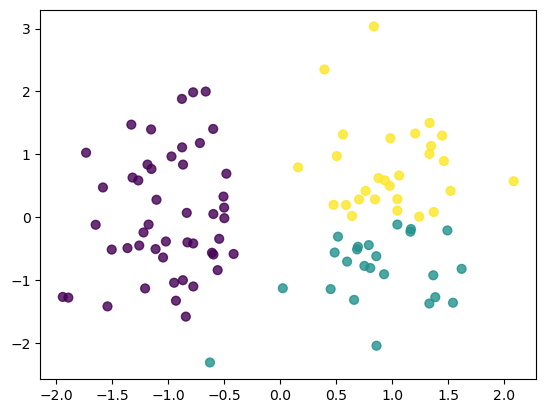

In [2]:
import os
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"

from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
%matplotlib inline

kmeans_model = KMeans(n_clusters=3, random_state=42)
kmeans_model.fit(X)

plt.scatter(X[:, 0], X[:, 1], s=40, c=kmeans_model.labels_, marker='o', alpha=0.8, label='data')
plt.show()

### 4.3 Домашнее задание высокого уровня

Мы узнали про эвристику, улучшающую алгоритм: запустить несколько раз алгоритм, запомнить, куда попали центроиды при каждом запуске, а потом усреднить координаты за все несколько запуска.

Попробуйте применить эту эвристику на практике:

* используйте 10 запусков алгоритма $k$-средних для $k=2$ с параметрами
<pre>
kmeans_model = KMeans(n_clusters=2, n_init=1, random_state=None, algorithm='full', max_iter=2)
</pre>
* в каждом запуске сохраняйте координаты центроидов общий массив $c$. См. `cluster_centers_ : array, [n_clusters, n_features]`
* визуализируйте координаты точек из $c$ на фоне исходного множества точек

Результат будет примерно такой:
![several_init_knn](https://248006.selcdn.ru/public/DS.%20Block%202.%20M7/several_init_knn.png)

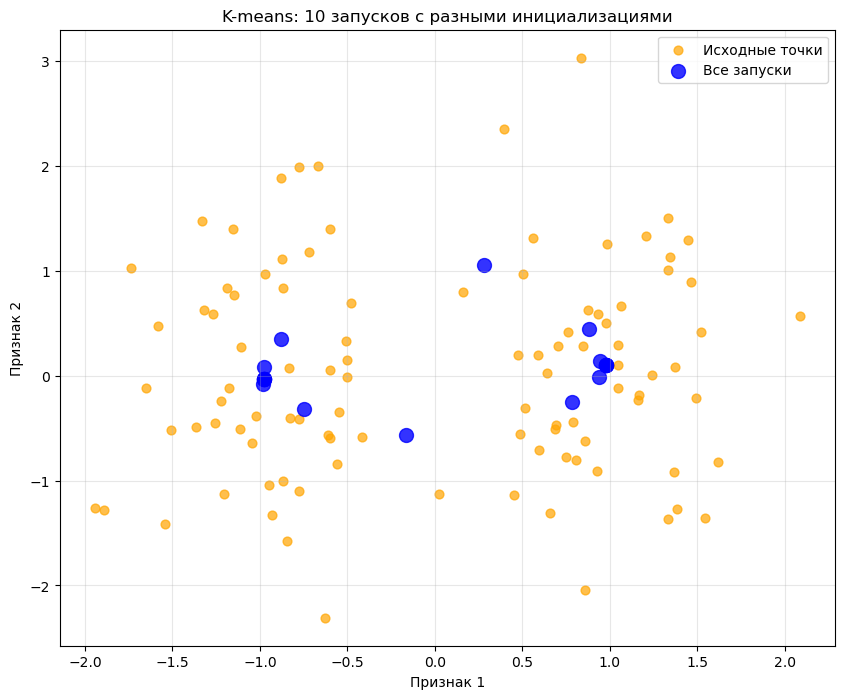

In [10]:

cluster_centers = []
for i in range(10):
    #создаем и обучаем новую модель для каждого запуска
    kmeans_model_1 = KMeans(n_clusters=2, n_init=1, random_state=None, algorithm='lloyd', max_iter=2)
    kmeans_model_1.fit(X)
    #сохраняем координаты центроидов
    cluster_centers.append(kmeans_model_1.cluster_centers_)

#преобразуем список центроидов в numpy массив
cluster_centers_array = np.array(cluster_centers)

#визуализация
plt.figure(figsize=(10, 8))

#отображаем исходные точки
plt.scatter(X[:, 0], X[:, 1], s=40, c='orange', marker='o', alpha=0.7, label='Исходные точки')
#преобразуем в 2D массив
all_centers = cluster_centers_array.reshape(-1, 2)
plt.scatter(all_centers[:, 0], all_centers[:, 1], s=100, c='b', marker='o', alpha=0.8, label='Все запуски')

plt.title('K-means: 10 запусков с разными инициализациями')
plt.xlabel('Признак 1')
plt.ylabel('Признак 2')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


Мы выяснили, что один из недостатков алгоритма k-средних состоит в том, что количество кластеров надо задать до тренировки модели, но как же определить, сколько будет кластеров в данных? Для этой задачи существует эффективный алгоритм, о котором мы поговорим в следующем уроке.